Mounted at /content/drive


In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
!pip install haversine
from haversine import haversine

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
#Load, check data
airport_df = pd.read_csv("South_Korea_airport_toy_example.csv")
airport_df

,Name,Type,IATA,ICAO,Longitude (deg),Latitude (deg)
0,Incheon,International,ICN,RKSI,126.4498,37.4465
1,Jeju,International,CJU,RKPC,126.4928,33.5111
2,Cheongju,International,CJJ,RKTU,127.4989,36.7164
3,Yangyang,International,YNY,RKNY,128.6689,38.0611
4,Pohang,Domestic,KPO,RKTH,129.4205,35.9879
5,Gimhae,International,PUS,RKPK,128.9381,35.1794


#Graph

In [ ]:
# https://www.bogotobogo.com/python/python_graph_data_structures.php
class Graph:
  def __init__(self):
    self.graph = {}
    self.weight= {}
  
  def __str__(self):
    res = []
    for node in self.graph:
      res.append(" ".join([str(node), ":", str(self.graph[node])]))
    return "\n".join(res)

  def print(self):
    res = []
    for node in self.graph:
      connections = self.graph[node]
      connection_str = ", ".join([f"('{n}', {self.weight[node][n]})" for n in connections])
      res.append(f"('{node}': {{{connection_str}}}')")
    print(",\n".join(res))


  def get_graph_dict(self):
    graph_dict = {}
    for node in self.graph:
        neighbors = self.graph[node]
        weights = {f"('{n}', {self.weight[node][n]})" for n in neighbors}
        graph_dict[node] = weights
    return graph_dict

  def add_vertex(self, start, end, weight=None):
    self.graph[start] = end
    if weight == None:
      weight = [0] * len(end)
      if len(end) == 0:
        weight = []
    self.add_edge(start, weight)

  def add_edge(self, node, weights):
    if len(weights) == 0:
      self.weight[node] = {}
    for i,n in enumerate(self.graph[node]):
      weight = weights[i]
      if node in self.weight:
        self.weight[node][n] = weight
      else:
        self.weight[node] = {n : weight}

  def get_vertices(self, node):
    return self.graph[node]

In [ ]:
#vertex
graph = Graph()
graph.add_vertex('CJU', ['ICN','CJJ','PUS'])
graph.add_vertex('ICN', ['CJJ', 'YNY'])
graph.add_vertex('CJJ', ['ICN', 'PUS', 'KPO'])
graph.add_vertex('PUS', ['CJJ','KPO'])
graph.add_vertex('KPO', ['CJJ', 'PUS', 'YNY'])
graph.add_vertex('YNY', [])

In [ ]:
#Add weight using havesine
for g in graph.graph:
  weights = []
  for n in graph.get_vertices(g):
    p1 = airport_df.loc[airport_df.IATA == g,['Latitude (deg)','Longitude (deg)']].values[0]
    p2 = airport_df.loc[airport_df.IATA == n,['Latitude (deg)', 'Longitude (deg)']].values[0]
    w = haversine(p1, p2, unit = 'km')
    weights.append(w)
  graph.add_edge(g, weights)

In [ ]:
#Representation
graph.print()

('CJU': {('ICN', 437.6144234862817), ('CJJ', 367.96727230059986), ('PUS', 291.20743894500595)}'),
('ICN': {('CJJ', 123.49657750039117), ('YNY', 206.71158605818974)}'),
('CJJ': {('ICN', 123.49657750039117), ('PUS', 214.45396265229365), ('KPO', 190.1964114912266)}'),
('PUS': {('CJJ', 214.45396265229365), ('KPO', 99.92598886731854)}'),
('KPO': {('CJJ', 190.1964114912266), ('PUS', 99.92598886731854), ('YNY', 239.98884640443018)}'),
('YNY': {}')


In [ ]:
# Structure Idea: https://gist.github.com/qpwo/cda55deee291de31b50d408c1a7c8515
graph_dict = graph.get_graph_dict()

g = {}
for node, neighbors in graph_dict.items():
    formatted_neighbors = {eval(n) for n in neighbors}
    g[node] = formatted_neighbors

g

{'CJU': {('CJJ', 367.96727230059986),
  ('ICN', 437.6144234862817),
  ('PUS', 291.20743894500595)},
 'ICN': {('CJJ', 123.49657750039117), ('YNY', 206.71158605818974)},
 'CJJ': {('ICN', 123.49657750039117),
  ('KPO', 190.1964114912266),
  ('PUS', 214.45396265229365)},
 'PUS': {('CJJ', 214.45396265229365), ('KPO', 99.92598886731854)},
 'KPO': {('CJJ', 190.1964114912266),
  ('PUS', 99.92598886731854),
  ('YNY', 239.98884640443018)},
 'YNY': set()}

# Dijkstra

In [ ]:
#https://gist.github.com/qpwo/cda55deee291de31b50d408c1a7c8515
import numpy as np
from queue import PriorityQueue

#for penalty_Chat GPT
def calculate_line_equation(a, b):
    ax, ay = a
    bx, by = b

    slope = (by - ay) / (bx - ax)
    intercept = ay - (slope * ax)

    x = (ax + bx) / 2
    if ax < bx:
        values = [(x, slope * x + intercept) for x in np.arange(ax, bx, 0.05)]
    else:
        values = [(x, slope * x + intercept) for x in np.arange(bx, ax, 0.05)]
    return values

def is_point_in_bad_area(points, bad):
    xmin, xmax = min(bad[0][0], bad[2][0]), max(bad[0][0], bad[2][0])
    ymin, ymax = min(bad[0][1], bad[1][1]), max(bad[0][1], bad[1][1])

    for point in points:
        x, y = point
        if xmin <= x <= xmax and ymin <= y <= ymax:
            return True
    return False

#algorithm
def dijkstra(G, start, goal, bad_regions):
    visited = set()
    cost = {start: 0}
    parent = {start: None}
    todo = PriorityQueue()
  
    todo.put((0, start))
    while not todo.empty():
        _, vertex = todo.get()
        if vertex in visited:
            continue
        visited.add(vertex)

        if vertex == goal:
            break

        for neighbor, distance in G[vertex]:
            if neighbor in visited:
                continue

            old_cost = cost.get(neighbor, float('inf'))
            new_cost = cost[vertex] + distance

            # Check if the edge between vertex and neighbor crosses any bad region
            v_cor = airport_df.loc[airport_df.IATA == vertex,['Longitude (deg)', 'Latitude (deg)']].values[0]
            n_cor = airport_df.loc[airport_df.IATA == neighbor,['Longitude (deg)', 'Latitude (deg)']].values[0]
            points = calculate_line_equation(v_cor, n_cor)

            # Check if the edge crosses any bad region
            crosses_bad_region = False
            for bad in bad_regions:
                if is_point_in_bad_area(points, bad):
                    crosses_bad_region = True
                    break

            if crosses_bad_region:
                continue  # Skip adding the edge if it crosses a bad region

            if new_cost < old_cost:
                todo.put((new_cost, neighbor))
                cost[neighbor] = new_cost
                parent[neighbor] = vertex

    return parent
#path calculation
def make_path(parent, goal):
    if goal not in parent:
        return None
    v = goal
    path = []
    while v is not None: # root has null parent
        path.append(v)
        v = parent[v]
    path = path[::-1]  # Reverse the path
    return {goal: path}
# distance calculation
def calculate_path_distance(graph, path):
    distance = 0
    for i in range(len(path) - 1):
        current_vertex = path[i]
        next_vertex = path[i + 1]
        edges = graph[current_vertex]
        for neighbor, dist in edges:
            if neighbor == next_vertex:
                distance += dist
                break
    return distance

In [ ]:
#Under good weather condition
parent = dijkstra(g, 'CJU', 'YNY', [])
path = make_path(parent, 'YNY')
distance = calculate_path_distance(g, path['YNY'])
print(path)
print(distance)

{'YNY': ['CJU', 'PUS', 'KPO', 'YNY']}
631.1222742167547


# Representation

In [ ]:
# plot
def represent(data, graph, path=[], bad=[]):
    plt.figure(figsize=(7, 7))
    plt.scatter(data['Longitude (deg)'], data['Latitude (deg)'], color='black')
    plt.xlabel('Longitude (deg)')
    plt.ylabel('Latitude (deg)')
    for i in range(len(data.IATA)):
        t = data['Name'][i]
        plt.text(data['Longitude (deg)'][i], data['Latitude (deg)'][i], t)

    done = {'CJU': True, 'ICN': True, 'CJJ': True, 'PUS': True, 'KPO': True, 'YNY': True}
    for g, neighbors in graph.items():
        for n, dist in neighbors:
            df_g = data[data.IATA == g]
            if done[n]:
                df_n = data[data.IATA == n]
                df = pd.concat([df_g, df_n])
                plt.plot(df['Longitude (deg)'], df['Latitude (deg)'], '--', color='black')
        done[g] = False

    # plot shortest path with red line
    for j in range(len(path)-1):
      vertex_a = path[j]
      vertex_b = path[j+1]
      df_a = data[data.IATA == vertex_a]
      df_b = data[data.IATA == vertex_b]
      plt.plot([df_a['Longitude (deg)'], df_b['Longitude (deg)']],
              [df_a['Latitude (deg)'], df_b['Latitude (deg)']],
              color='red')

    # plot bad weather region
    for i, bad_condition in enumerate(bad):
      shp_i = patches.Rectangle(bad[0],
            bad[2][0] - bad[0][0], bad[1][1] - bad[0][1],
            color = 'red')
      plt.gca().add_patch(shp_i)

    plt.grid(True)
    plt.show()


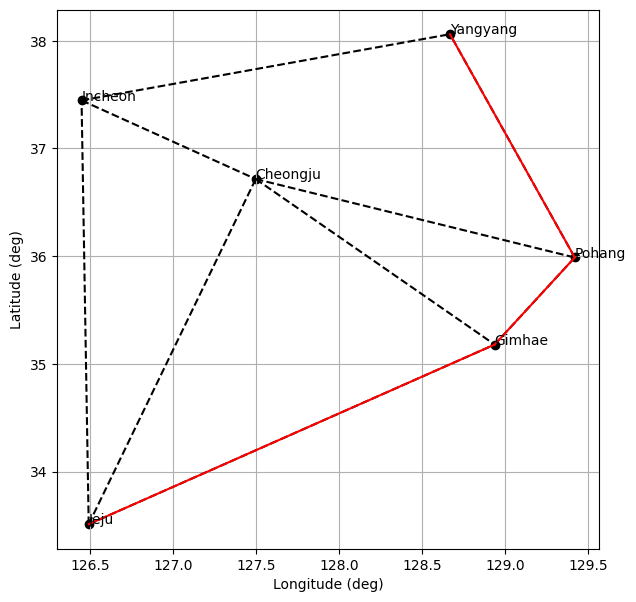

In [ ]:
#Good condition
represent(airport_df, g, path['YNY'])

##Bad Weather

In [ ]:
bad = [(128.7, 36.6), (128.7, 37.6), (129.3, 37.6), (129.3, 36.6)]
parent = dijkstra(g, 'CJU', 'YNY', [bad])
path = make_path(parent, 'YNY')
distance = calculate_path_distance(g, path['YNY'])
print(path)
print(distance)

{'YNY': ['CJU', 'ICN', 'YNY']}
644.3260095444714


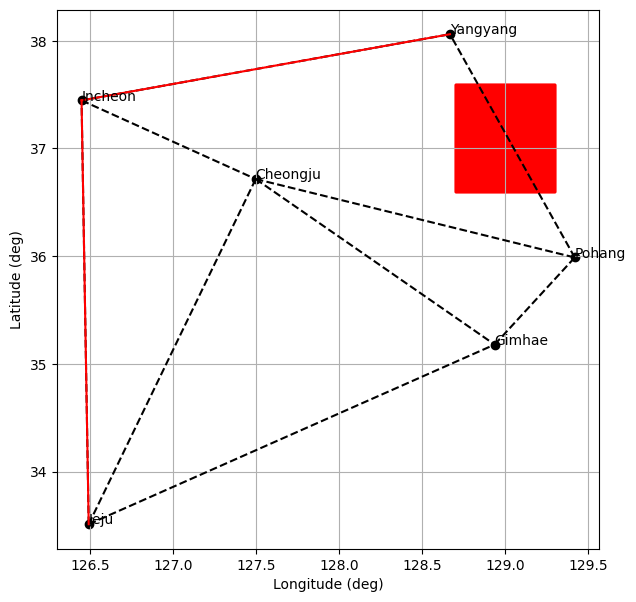

In [ ]:
represent(airport_df, g, path['YNY'], bad)

# Sources:
* 262588213843476. “Dijkstra’s Algorithm in Python Using Priorityqueue. Quits Early upon Goal Discovery. More like Uniform Cost Search Actually. Fast.” Gist, gist.github.com/qpwo/cda55deee291de31b50d408c1a7c8515. Accessed 21 May 2023. 
* “Graphs in Python - Theory and Implementation.” Stack Abuse, stackabuse.com/courses/graphs-in-python-theory-and-implementation/lessons/dijkstras-algorithm/. Accessed 21 May 2023. 
* “Python Tutorial.” Python Tutorial: Dijkstra’s Shortest Path Algorithm - 2020, bogotobogo.com/python/python_Dijkstras_Shortest_Path_Algorithm.php. Accessed 21 May 2023. 
* “Python Tutorial.” Python Tutorial: Graph Data Structure - 2021, www.bogotobogo.com/python/python_graph_data_structures.php. Accessed 21 May 2023. 
* chat GPT